# Hidden CKD

#### Features
The following are the features used in this study in order of appearance
- Date of event: Date of the screening
- Gender: Gender of the patient (M: Male, F: Female)
- Ethnicity: The ethnicity of the participant
- Age: Age of the patient (years)
- Height (cm): Height of the participant in cm
- Weight (kg): Weight of the participant in kg
- BMI: BMI of the participant
- BMI Category: Classification of the particpant BMI according to NICE guidelines
- Systolic, Diastolic: The systolic and diastolic of the partcipants
- Pulse Pressure: 
- BP Category: Classification of the particpant BP according to NICE guidelines
- Has High BP:
- Has Diabetes
- Has Kidney Disease
- On BP Medication?
- On Diabetes Medication?
- On Cholesterol Medication?
- On Other Medication?
- Family History of Kidney Disease: Whether the patient has a family history of kidney disease (Definitely Yes, Definitely Not, Not Sure)
- uACR: Urine albumin to creatinine ratio of the participants as measured using a urine dipstick (Normal, Abnormal, High Abnormal)
- CKD Risk: A calculation of CKD risk by combining research findings

This is how CKD risk is calculated

low risk = sys<140, dia<90, uACR='Normal', Has_Diabetes=False or Family_KD=False<br>
moderate risk = sys<140, dia<90, uACR='Abnormal', Has_Diabetes=True or Family_KD=True<br>
high risk = sys>=180, dia>=120, uACR='High Abnormal', Has_Diabetes=False or Family_KD=False<br>

In [161]:
import numpy as np
import pandas as pd
from src.config import PROCESSED_DATA_DIR

In [162]:
filename = PROCESSED_DATA_DIR / 'hidden_ckd_processed.csv'
df = pd.read_csv(filename)
df.head()

,Date,Gender,Ethnicity,S_Ethnicity,Ethnicity_Black,DOB,Age,Age_Category,Height,Weight,...,Has_Diabetes,Has_KD,Has_HD,BP_Meds,Diabetes_Meds,Cholesterol_Meds,Other_Meds,Family_KD,uACR,CKD_Risk
0,23/10/2022,Male,Black Caribbean,Black,True,21/05/1946,76.5,>70,161.0,64.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate
1,23/10/2022,Male,Black African (West Africa),Black,True,25/01/1970,52.8,41-55,163.0,78.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate
2,26/08/2023,Male,Black Caribbean,Black,True,14/07/2005,18.1,<25,167.0,91.0,...,False,False,False,False,False,False,False,Definitely not,Normal,Low
3,28/04/2023,Male,Black Caribbean,Black,True,25/04/1969,54.0,41-55,168.0,87.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate
4,06/11/2022,Female,Black African (West Africa),Black,True,03/11/1979,43.0,41-55,187.0,109.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate


## ML Models (without Using Blood Pressure Readings)

In [163]:
# Import modules
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.impute import SimpleImputer
from src.config import MODELS_DIR
import joblib

In [164]:
from src.utils.model_utils import (resample_data, stratified_split, random_split,
                                   load_model, evaluate_model)
from src.utils.models import (train_ensemble1, train_ensemble2, train_gnb,
                              train_knn, train_lr, train_rf, train_xg, train_regressor)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [165]:
from imblearn.over_sampling import SMOTENC

num_features = ['Age', 'Height', 'Weight', 'Systolic', 'Diastolic']
nom_features = ['Family_KD', 'uACR']
ord_features = ['Has_Hpt', 'Has_Diabetes', 'Ethnicity_Black']

X = df[num_features + nom_features + ord_features]
y = df['CKD_Risk']

resampler = SMOTENC(sampling_strategy='not majority', random_state=42, categorical_features=[5, 6])
X_res, y_res = resampler.fit_resample(X, y)

In [166]:
# Creating preprocessing pipelines for both numeric and nominal and ordinal data.
num_features = ['Age', 'Height', 'Weight']
num_transformer = Pipeline(steps=[
    ('scaler', PowerTransformer(method='yeo-johnson'))])

nom_features = ['Family_KD']
nom_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])

ord_features = ['Has_Hpt', 'Has_Diabetes', 'Ethnicity_Black']
ord_categories = [[False, True] for _ in ord_features]
ord_transformer = Pipeline(steps=[
    ('ord_enc', OrdinalEncoder(categories=ord_categories))
])

# Combining everything into one preprocessor
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('nom', nom_transformer, nom_features),
        ('ord', ord_transformer, ord_features)])


In [167]:
# Define regression features and targets
X = X_res[num_features + nom_features + ord_features]
y = X_res[['Systolic', 'Diastolic']]

# Split into train and test and apply preprocessing/scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_processed = preprocessor_reg.fit_transform(X_train)
X_test_processed = preprocessor_reg.transform(X_test)
preprocessor_filename = 'preprocessor_reg.pkl'
joblib.dump(preprocessor_reg, MODELS_DIR / preprocessor_filename)

# Train regressor
model_filename = 'bp_regressor.pkl'
regressor = train_regressor(X_train_processed, y_train, model_filename)

y_pred = regressor.predict(X_test_processed)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print(f'Tuned MSE for Systolic: {mse[0]:.2f}')
print(f'Tuned MSE for Diastolic: {mse[1]:.2f}')


Fitting 10 folds for each of 720 candidates, totalling 7200 fits
Best hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 100, 'subsample': 0.6}
Tuned MSE for Systolic: 241.38
Tuned MSE for Diastolic: 86.78


In [168]:
from sklearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.model_selection import train_test_split
from src.utils.model_utils import stratified_split
from src.config import MODELS_DIR
import joblib

# Define features
df[['Systolic', 'Diastolic']] = pd.DataFrame(regressor.predict(preprocessor_reg.transform(X)))
num_features = ['Age', 'Height', 'Weight', 'Systolic', 'Diastolic']
nom_features = ['S_Ethnicity', 'Family_KD', 'Gender']
ord_features = ['Has_Hpt', 'Has_Diabetes']

X = df[num_features + nom_features + ord_features]
y = df['CKD_Risk'].map({'Low': 0, 'Moderate': 1, 'High': 2})

# Apply basic preprocessing to all data
basic_preprocessor = joblib.load(MODELS_DIR / 'basic_preprocessor_bp.pkl')
X_preprocessed = basic_preprocessor.transform(X)

# Train/test split on preprocessed data
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, stratify=y, random_state=42)

# Resample training set
resampler = ADASYN(sampling_strategy='minority', random_state=42)
X_train, y_train = resampler.fit_resample(X_train, y_train)

# Fit scaler on resampled training and test data
scaling_transformer = joblib.load(MODELS_DIR / 'scaler_bp.pkl')
X_train = scaling_transformer.transform(X_train)
X_test = scaling_transformer.transform(X_test)

print(f"Original training shape: {X_train.shape}")
print(f"After resampling training shape: {X_train.shape}")
print(f"Final training shape: {X_train.shape}")
print(f"Final test shape: {X_test.shape}")


Original training shape: (1176, 18)
After resampling training shape: (1176, 18)
Final training shape: (1176, 18)
Final test shape: (193, 18)


Fitting 5 folds for each of 2700 candidates, totalling 13500 fits
Best Parameters: {'priors': [0.1, 0.5, 0.4], 'var_smoothing': 0.03944206059437664}

Accuracy: 0.46113989637305697

Classification Report:
               precision    recall  f1-score   support

         Low       0.54      0.70      0.61        53
    Moderate       0.85      0.32      0.46       122
        High       0.16      0.72      0.27        18

    accuracy                           0.46       193
   macro avg       0.52      0.58      0.45       193
weighted avg       0.70      0.46      0.49       193



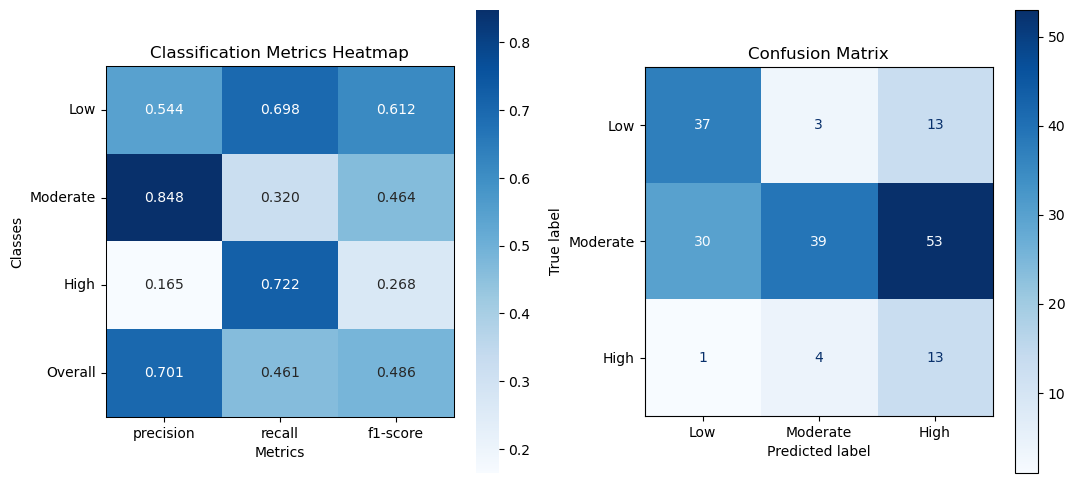

In [ ]:
# Import modules
from src.utils.models import train_xg, train_rf, train_knn, train_lr, train_gnb, train_ensemble2
from src.utils.model_utils import load_model, evaluate_model

# Load test data
target_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}

# Load model
model_filename = 'classifier_nobp.pkl'
#classifer = train_xg(X_train, y_train, model_filename)
#classifer = train_rf(X_train, X_test, y_train, y_test, model_filename)
#classifer = train_knn(X_train, y_train, model_filename)
#classifer = train_lr(X_train, y_train, model_filename)
#classifer = train_gnb(X_train, y_train, model_filename)
classifer = train_ensemble2(X_train, y_train, model_filename)

# Evaluate model
evaluate_model(classifer, X_test, y_test, target_mapping)

In [185]:
data = pd.DataFrame([{
    'Age': 66,
    'Height': 160,
    'Weight': 100,
    'S_Ethnicity': 'Black',
    'Family_KD': 'Definitely yes',
    'Gender': 'Male',
    'Has_Hpt': True,
    'Has_Diabetes': True,
    'Ethnicity_Black':True
}])

X = data[['Age', 'Height', 'Weight', 'Family_KD', 'Has_Hpt', 'Has_Diabetes', 'Ethnicity_Black']]

# Predict sytolic and diastolic
X_transformed = preprocessor_reg.transform(X)
data[['Systolic', 'Diastolic']] = regressor.predict(X_transformed)
data = data[['Age', 'Height', 'Weight', 'Systolic', 'Diastolic',
             'S_Ethnicity', 'Gender', 'Family_KD', 'Has_Hpt', 'Has_Diabetes']]

# Run pipeline
full_pipeline = Pipeline(steps=[
    ('basic_preprocessor', basic_preprocessor),
    ('scaler', scaling_transformer),
    ('model', classifer)
])

target_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
reverse_mapping = {v: k for k, v in target_mapping.items()}

# Predict risk level
prediction = full_pipeline.predict(data)
predicted_risk = reverse_mapping[prediction[0]]
print("Predicted Risk Level:", predicted_risk)

# Print class probabilities as risk labels
probabilities = full_pipeline.predict_proba(data)
print("Risk Level Probabilities:")
for cls, prob in enumerate(probabilities[0]):
    print(f"  {reverse_mapping[cls]}: {prob:.4f}")


Predicted Risk Level: High
Risk Level Probabilities:
  Low: 0.0000
  Moderate: 0.2024
  High: 0.7976


In [186]:
data

,Age,Height,Weight,Systolic,Diastolic,S_Ethnicity,Gender,Family_KD,Has_Hpt,Has_Diabetes
0,66,160,100,143.757126,76.234978,Black,Male,Definitely yes,True,True
